In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# to create initial centers

c_available = []
for i in range(3):
    c = [0, 0, 0]
    rand_idx = np.random.choice([0, 1, 2], size=3)
    c[rand_idx] = np.random.choice([0, 1, -1])

In [11]:
c_0 = (0,0,0) # this is what a center means. 

occupied_centers = {c_0 , (1,0,0), (0,1,0)}
# Initializing parameter values
## available parameter values
par_values = [1, 0]

# Running the algorithm
N = 10 # number of iterations


for i in range(N):
    p = np.random.choice(par_values, size=3) # gives us a random array of parameter values for 3 different paramters. Index 0 = x, Index 1 = y and Index 2 = z
# print(p)
    # p = [1, 1, 1]

    directions = [(1, 0, 0), (-1, 0, 0), (0, 1, 0), (0, -1, 0), (0, 0, 1), (0, 0, -1)]
    active_centers = occupied_centers.copy()

    for j, par in enumerate(p):
        axis_of_interest = directions[2*j:2*j+2]
        if par == 0:
            continue
        else:
            candidate_sites = []
            for cx, cy, cz in active_centers:
                for dx, dy, dz in axis_of_interest:
                    neighbor = (cx + dx, cy + dy, cz +dz)
                    if neighbor not in occupied_centers:
                        candidate_sites.append([(cx, cy, cz),neighbor]) 
            
            new_center =  candidate_sites[np.random.choice(len(candidate_sites))]
            occupied_centers.add(new_center[1]) 
            active_centers.remove(new_center[0])
            active_centers.add(new_center[1])
            
        # print(active_centers)
    

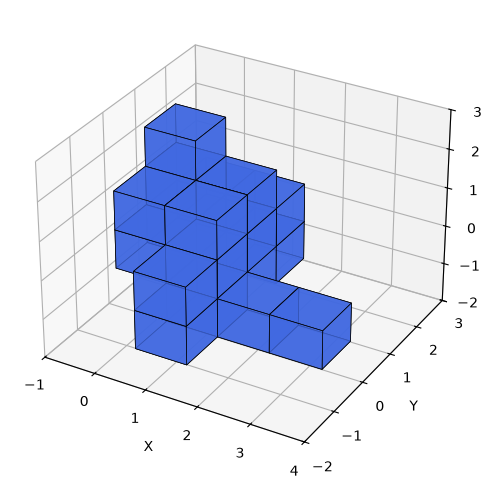

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np

# 1. Setup your figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')

# 2. Helper function to generate the 6 faces of a unit cube
def get_cube_faces(center, size=1.0):
    cx, cy, cz = center
    r = size / 2.0  # Distance from center to edge (0.5 for a unit cube)
    
    # The 8 vertices of a cube
    corners = np.array([
        [cx-r, cy-r, cz-r], [cx+r, cy-r, cz-r], [cx+r, cy+r, cz-r], [cx-r, cy+r, cz-r], # Bottom
        [cx-r, cy-r, cz+r], [cx+r, cy-r, cz+r], [cx+r, cy+r, cz+r], [cx-r, cy+r, cz+r]  # Top
    ])
    
    # Map vertices to the 6 faces
    faces = [
        [corners[0], corners[1], corners[2], corners[3]], # Bottom face
        [corners[4], corners[5], corners[6], corners[7]], # Top face
        [corners[0], corners[1], corners[5], corners[4]], # Front face
        [corners[2], corners[3], corners[7], corners[6]], # Back face
        [corners[1], corners[2], corners[6], corners[5]], # Right face
        [corners[0], corners[3], corners[7], corners[4]]  # Left face
    ]
    return faces

# 3. Collect all faces for every point in your lattice
all_faces = []
for center in occupied_centers:
    all_faces.extend(get_cube_faces(center, size=1.0))

# 4. Render the cubes
# edgecolors='black' gives a nice grid outline so the cubes don't blend together
cubes = Poly3DCollection(all_faces, facecolors='royalblue', linewidths=0.5, edgecolors='black', alpha=0.8)
ax.add_collection3d(cubes)

# 5. Manually set the axes limits (Required for Poly3DCollection)
if occupied_centers:
    x_vals = [c[0] for c in occupied_centers]
    y_vals = [c[1] for c in occupied_centers]
    z_vals = [c[2] for c in occupied_centers]
    
    # Add a buffer of 1 unit around the cluster so it isn't cramped
    ax.set_xlim(min(x_vals) - 1, max(x_vals) + 1)
    ax.set_ylim(min(y_vals) - 1, max(y_vals) + 1)
    ax.set_zlim(min(z_vals) - 1, max(z_vals) + 1)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

In [1]:
a={1}
a.add(2)
print(a)

{1, 2}
